First 5 rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset after preprocessing:
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0

Number of samples: 150

Training samples: 120
Testing samples: 30

K-NN Model Trained Successfully!
Number of Neighbors (K): 5

Predicted Results:
[0 2 1 1 0 1 0 0 2 

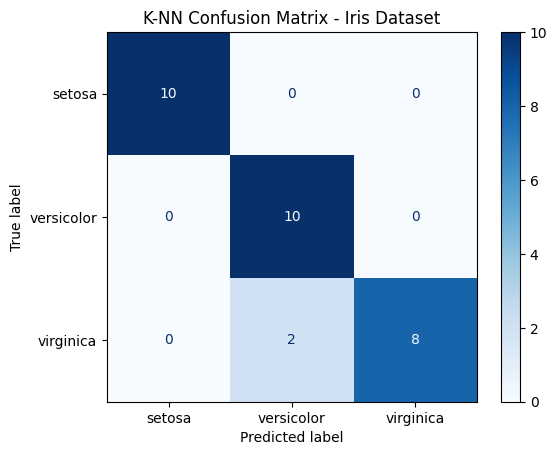

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# --------------------------------------------------
# Loading the Dataset
# --------------------------------------------------

dataset = pd.read_csv("/content/iris.csv")

print("First 5 rows of the dataset:")
print(dataset.head())

print("\n" + "=" * 60)

# --------------------------------------------------
# Selecting Required Columns
# --------------------------------------------------

dataset = dataset[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width",
        "species"
    ]
]

# --------------------------------------------------
# Removing Rows with Missing Values
# --------------------------------------------------

dataset = dataset.dropna()

# --------------------------------------------------
# Converting Species into Numerical Values
# --------------------------------------------------

encoder = LabelEncoder()

dataset["species"] = encoder.fit_transform(dataset["species"])

print("Dataset after preprocessing:")
print(dataset.head())

print("\n" + "=" * 60)

# --------------------------------------------------
# Separating Input Features and Target
# --------------------------------------------------

X = dataset.drop("species", axis=1)

y = dataset["species"]

print("Number of samples:", len(dataset))

print("\n" + "=" * 60)

# --------------------------------------------------
# Splitting into Training and Testing Data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\n" + "=" * 60)

# --------------------------------------------------
# Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------------
# Creating and Training the K-NN Model
# --------------------------------------------------

k = 5

model = KNeighborsClassifier(
    n_neighbors=k
)

model.fit(X_train, y_train)

print("K-NN Model Trained Successfully!")
print("Number of Neighbors (K):", k)

print("\n" + "=" * 60)

# --------------------------------------------------
# Making Predictions
# --------------------------------------------------

y_pred = model.predict(X_test)

print("Predicted Results:")
print(y_pred)

print("\nActual Results:")
print(y_test.values)

print("\n" + "=" * 60)

# --------------------------------------------------
# Evaluating the Model
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

print("\n" + "=" * 60)

# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\n" + "=" * 60)

# --------------------------------------------------
# Classification Report
# --------------------------------------------------

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# --------------------------------------------------
# Visualizing the Confusion Matrix
# --------------------------------------------------

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

display.plot(cmap="Blues")

plt.title("K-NN Confusion Matrix - Iris Dataset")

plt.show()
